In [1]:
import matplotlib.pyplot as plt
import numpy as np
import eq_solver
from eq_solver import activity_models as am
from eq_solver.system import Species, Phase
from dataclasses import replace

# Activity coefficient 

In [2]:
Mg = Species(name="Mg", phase=Phase.LIQUID)
Mg_exDH = replace(Mg, a=0.80)
Mg_TJ = replace(Mg, a=0.55, b=0.2)

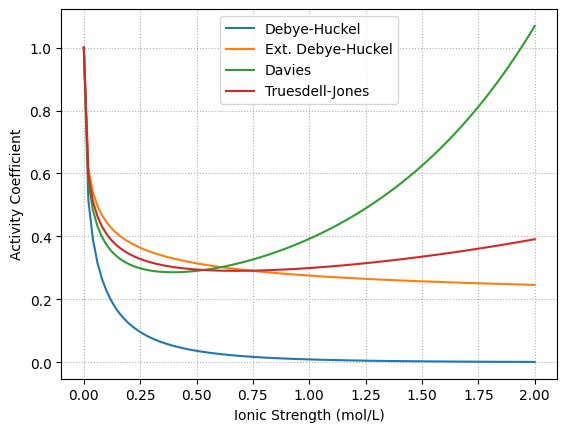

In [3]:
I = np.linspace(0, 2, 100)
gamma_DH = am.debye_huckel(I, 2, 298.15)
gamma_exDH = am.ex_debye_huckel(I, 2, 298.15, Mg_exDH.a)
gamma_TJ = am.truesdell_jones(I, 2, 298.15, Mg_TJ.a, Mg_TJ.b)
gamma_Dv = am.davies(I, 2, 298.15)
plt.show()
plt.plot(I, gamma_DH, label="Debye-Huckel")
plt.plot(I, gamma_exDH, label="Ext. Debye-Huckel")
plt.plot(I, gamma_Dv, label="Davies")
plt.plot(I, gamma_TJ, label="Truesdell-Jones")
plt.grid(True, ls=':')
plt.legend()
plt.xlabel('Ionic Strength (mol/L)')
plt.ylabel('Activity Coefficient')
plt.show()

# pH of NaHCO3 solution with different concentration, w/ or w/o activity coefficient

In [4]:
from dataclasses import replace
s_davies = eq_solver.System.from_yaml('./Na-CO3-nogas.yaml')
s_none = replace(s_davies, activity_model='none')
from pprint import pprint
pprint(s_davies)

System(activity_model='davies',
       species=(Species(name='H+'),
                Species(name='OH-'),
                Species(name='Na+'),
                Species(name='CO2aq'),
                Species(name='HCO3-'),
                Species(name='CO3^2-')),
       components=(Component(name='proton',
                             base_species=Species(name='H+'),
                             constraint=<Constraint.CHARGE: 1>,
                             charge=1),
                   Component(name='carbonate',
                             base_species=Species(name='CO2aq'),
                             constraint=<Constraint.TOTAL: 0>,
                             charge=0),
                   Component(name='sodium',
                             base_species=Species(name='Na+'),
                             constraint=<Constraint.DIRECT: 2>,
                             charge=1)),
       temperature=298.15,
       specs=SystemSpecs(n_vars=3,
                         n_loga=2,
     

In [8]:
c_list = np.logspace(-5, -1, 20)
cond_list_davies = [eq_solver.Conditions.from_dict(s_davies, {'carbonate': c, 'sodium': c}) for c in c_list]
cond_list_none = [eq_solver.Conditions.from_dict(s_none, {'carbonate': c, 'sodium': c}) for c in c_list]
r_davies = eq_solver.solve_for_conditions(s_davies, cond_list_davies)
r_none = eq_solver.solve_for_conditions(s_none, cond_list_none)

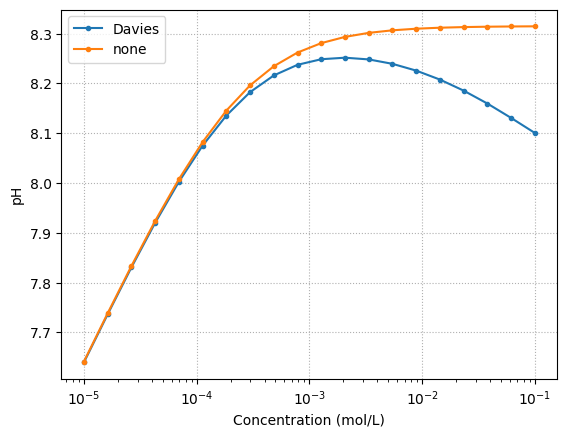

In [9]:
plt.figure()
plt.plot(c_list, [r.pH() for r in r_davies], '.-', label='Davies')
plt.plot(c_list, [r.pH() for r in r_none], '.-', label='none')
plt.legend()
plt.grid(True, ls=':')
plt.xlabel('Concentration (mol/L)')
plt.ylabel('pH')
plt.xscale('log')
plt.show()